In [37]:
from qiskit import QuantumCircuit, transpile                                
from qiskit_ibm_runtime import QiskitRuntimeService, Sampler, Session     
import numpy as np



In [38]:
m = 2  # address qubits
d = 1 # data qubits
alpha = np.array([1/np.sqrt(2**m)] * (2**m), dtype=complex)

assert np.isclose(np.sum(np.abs(alpha)**2), 1)

qc = QuantumCircuit(m+d, name="AddressPrep")

qc.initialize(alpha, range(m))

#La preparazione dello stato dell’address register viene modellata come una procedura di state preparation ideale, 
#producendo una sovrapposizione uniforme degli indirizzi. Tale assunzione è coerente con il modello teorico di QRAM bucket-brigade, 
#in cui il costo della preparazione degli indirizzi è separato dal costo dell’accesso alla memoria.

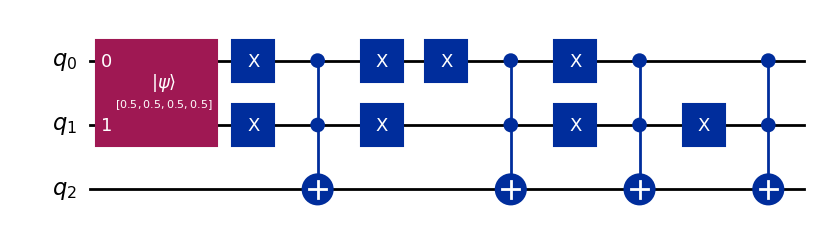

In [39]:
memory = {
    "00" : 1,
    "01" : 1,
    "10" : 1,
    "11" : 1
}

for addr, value in memory.items():  
    if value == 1:
        for i, bit in enumerate(addr):
            if bit == "0":
                qc.x(i)
        
        # assuming an ancilla/data qubit at position m
        qc.mcx(control_qubits=list(range(m)), target_qubit=m)

        for i, bit in enumerate(addr):
            if bit == "0":
                qc.x(i)

qc.draw("mpl")